# ftir_28 — the MA350 cannot measure a brown-carbon share at Addis

## tl;dr

**The MA350 cannot measure a brown-carbon share at Addis.** That is a statement about the
instrument, not about the atmosphere — nothing here says Addis has little brown carbon.
`INTERCEPT_ATTACK_PLAN.md` item 4 proposed using the MA350's wavelength spread to estimate
BrC absorption at the HIPS wavelength, subtract it from Fabs, and see whether the intercept
closes. Tested on MA350-0238 over 515 ETAD filter-days, it fails twice over. **(1) There is
no red excess to attribute.** AAE(625, 880) from b_ATN is **0.944 ± 0.060** — *below* the
AAE_BC ≈ 1 anchor, not above it, on 84.5% of days — so the implied Babs_BrC is **−2.06 Mm⁻¹**
on average, negative on **84.5%** of days, and above the target on none, against the
**+21.7 Mm⁻¹** the intercept needs (C = |b|·MAC/a across the six ftir_19 setups, 18.8–26.1,
mean 21.7). Closing it this way would require **AAE_BC ≈ 0.31**, i.e. black carbon absorbing
more at 880 nm than at 625 nm. **(2) The instrument cannot be asked again, in either
direction.** Only IR is trustworthy: the Green channel implies an unphysical **negative** AAE
(median −0.168, 45% below the power law through its own neighbours), UV is out of range on
**35.0%** of days (BCc ≤ 0, or less absorption at 375 than at 880 nm; r with IR = 0.08), and
Red reproduces IR to within an **IQR of ±1.3%**. A channel-to-channel absolute error of 45%
is demonstrated on this instrument; the red excess being sought is a 24% shift. Two live repo
traps surfaced and are re-derived here (both fixed in `3aedfdc`): the AE33-vs-MA350 wavelength
confusion in `processed_sites/README.md` (×1.189 on AAE(Red, IR), enough to manufacture a
12.5% biomass share from a record with none), and the exact BCc-AAE offset identity
(**−1.0157** UV/IR, **−0.9674** Red/IR, re-derived from the firmware σ_ATN table), which cuts
the UV/IR biomass class from 52% to 20%. One positive result rides along: FTIR EC against
MA350 BC(880) — where BrC barely absorbs — gives intercept **+0.32 µg/m³** (95% CI +0.01 to
+0.63, R² **0.868**, n = 173), ~13× smaller than the −4.17 on the HIPS side and of the
opposite sign, which exonerates the FTIR axis and localizes the additive offset to the
HIPS-side 633 nm optics.

## Context & Methods

`INTERCEPT_ATTACK_PLAN.md` item 4 proposed the most decisive analysis available without
new sampling: the Addis intercept restates as **C = |b|·MAC/a ≈ 20 Mm⁻¹ of constant,
EC-free absorption at the HIPS wavelength (~633 nm)** (ftir_19, ftir_25). Brown carbon
absorbs steeply toward the UV and barely at 880 nm, so a five-channel MA350 collocated
with the ETAD filters should be able to say whether ~20 Mm⁻¹ of non-BC absorption is
sitting in Fabs: anchor AAE_BC ≈ 1 at 880 nm, attribute the 625 nm excess over that
anchor to BrC, and read off Babs_BrC per filter-day. Item 5 then subtracts it and
re-crossplots.

**This notebook is the committed record that the route fails, and of why it cannot be
rescued.** It is written up because "we tested it and closed it" is load-bearing in the
upcoming briefing, and a closed door needs the same evidentiary standard as an open one.

The conclusion is about the instrument, not about the atmosphere. The MA350 at Addis has
one trustworthy channel (IR) and three that return values no real aerosol can produce, so
it cannot resolve a red excess **in either direction**. Nothing here is evidence that
Addis has little brown carbon — the sign of the answer is not the finding, the absence of
a usable measurement is.

Three conventions this notebook is careful about, each of which has already produced a
wrong number somewhere in this repo:

1. **Which instrument.** `config.WAVELENGTHS_NM` is the MA350 set (375/470/528/625/880);
   `config.AE33_WAVELENGTHS_NM` (370/470/520/590/660/880/950) is a different instrument.
   Substituting the AE33 red channel inflates AAE(Red, IR) by ~19 %. The identity of the
   Addis instrument is established from the data below, not assumed.
2. **The AAE sign convention.** AAE is computed with `optics.aae` /
   `optics.aae_from_columns`, never inline. Four notebooks previously used
   `ln(IR/UV)/ln(880/375)`, the exact negative of the standard definition, which is ≤ 0
   for real aerosol and classified every sample as fossil fuel. The helper raises if the
   wavelengths are passed short/long the wrong way round; that guard is exercised below.
3. **BCc is not absorption.** The firmware has already divided attenuation by a
   wavelength-dependent ATN cross-section, so an AAE taken from BCc columns differs from
   the absorption AAE by an exact constant. Everything optical here is computed from
   b_ATN = BCc × σ_ATN(λ), with σ_ATN re-derived from the vendored firmware constants in
   `src/external/calibration.py`.

**Scale caveat, stated once and carried throughout.** b_ATN is attenuation-scale, not
Fabs-scale: it omits the multiple-scattering correction C, and at Addis its 625 nm median
runs about 2× the median HIPS Fabs. AAE is invariant to that factor (it cancels in the
ratio), so Part 1's central result does not depend on it; the Babs_BrC *magnitudes* are
quoted on the b_ATN scale and would shrink by ~2× on the Fabs scale. Both are reported.
A negative number stays negative under any positive rescaling, which is the only property
the falsification needs.

In [1]:
%matplotlib inline
import ast
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import brentq
from IPython.display import display

from config import WAVELENGTHS_NM, AE33_WAVELENGTHS_NM, AAE_REGIONS, PROCESSED_SITES_DIR
from optics import aae, aae_from_columns, aae_source_summary
from data_matching import load_filter_data
from pls_transfer import regression_metrics

REPO_ROOT = Path('..').resolve().parent
TABLE_DIR = Path('output/tables/ftir28')
PLOT_DIR = Path('output/plots/ftir28')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
ACCENT, BLUE, PURPLE, GREEN, GREY = '#B23327', '#2C6E9E', '#7A4FA3', '#3C7A52', '#8F8C84'
CHANNEL_COLOUR = {'UV': PURPLE, 'Blue': BLUE, 'Green': GREEN, 'Red': ACCENT, 'IR': INK}

## Data

### Which pickle is the ETAD-collocated Addis MA350 record

`processed_sites/` holds two candidates for "the Addis instrument".
`df_Jacros_9am_resampled.pkl` is the full deployment record of the instrument at the
Jacros site (Apr 2022 – Jun 2025); `df_Addis_Ababa_9am_resampled.pkl` is the same
instrument restricted to days within ±1 of an ETAD filter and carrying the `ETAD`
site code. The check below confirms they are the same serial number and that the daily
values agree exactly on shared days, so the ETAD-collocated record is the Addis Ababa
file — that is the one every number in this notebook uses.

The channel set is read off the columns: five channels named UV/Blue/Green/Red/IR, which
is the microAeth MA-series layout. An AE33 export would carry `BC1`–`BC7`. The assertions
make the instrument identification a test rather than a comment.

In [2]:
addis = pd.read_pickle(PROCESSED_SITES_DIR / 'df_Addis_Ababa_9am_resampled.pkl')
jacros = pd.read_pickle(PROCESSED_SITES_DIR / 'df_Jacros_9am_resampled.pkl')
for frame in (addis, jacros):
    frame['day_9am'] = pd.to_datetime(frame['day_9am'])

CHANNELS = ['UV', 'Blue', 'Green', 'Red', 'IR']
print('Addis Ababa file : %d filter-days, %s to %s'
      % (len(addis), addis['day_9am'].min().date(), addis['day_9am'].max().date()))
print('  Site_Code %s | Site_Name %s | Serial number %s | device_type %s'
      % (list(addis['Site_Code'].unique()), list(addis['Site_Name'].unique()),
         list(addis['Serial number'].dropna().unique()),
         sorted(addis['device_type'].dropna().unique())))
print('Jacros file      : %d days, %s to %s | Serial number %s'
      % (len(jacros), jacros['day_9am'].min().date(), jacros['day_9am'].max().date(),
         list(jacros['Serial number'].dropna().unique())))

shared = addis[['day_9am', 'IR BCc']].merge(jacros[['day_9am', 'IR BCc']], on='day_9am',
                                            suffixes=('_addis', '_jacros'))
assert len(shared) == len(addis)
assert np.allclose(shared['IR BCc_addis'], shared['IR BCc_jacros'])
print('  the %d Addis days are a subset of the Jacros record and agree exactly '
      '-> one instrument, two extracts' % len(shared))

# The instrument identity, asserted from the columns rather than assumed.
assert list(addis['Serial number'].dropna().unique()) == ['MA350-0238']
assert all(f'{name} BCc' in addis.columns for name in CHANNELS)
assert not any(f'BC{k}' in addis.columns for k in range(1, 8)), 'BC1..BC7 would mean an AE33'
assert set(CHANNELS) == set(WAVELENGTHS_NM)
assert WAVELENGTHS_NM != {k: v for k, v in AE33_WAVELENGTHS_NM.items()}
print('\nInstrument: microAeth MA350-0238, five channels -> config.WAVELENGTHS_NM')
print('  MA350 (used here) :', {k: WAVELENGTHS_NM[k] for k in CHANNELS})
print('  AE33  (NOT used)  :', AE33_WAVELENGTHS_NM)

Addis Ababa file : 515 filter-days, 2022-12-06 to 2024-09-22
  Site_Code ['ETAD'] | Site_Name ['Addis_Ababa'] | Serial number ['MA350-0238'] | device_type ['MA350', 'WF0013']
Jacros file      : 1047 days, 2022-04-13 to 2025-06-25 | Serial number ['MA350-0238']
  the 515 Addis days are a subset of the Jacros record and agree exactly -> one instrument, two extracts

Instrument: microAeth MA350-0238, five channels -> config.WAVELENGTHS_NM
  MA350 (used here) : {'UV': 375, 'Blue': 470, 'Green': 528, 'Red': 625, 'IR': 880}
  AE33  (NOT used)  : {'BC1': 370, 'BC2': 470, 'BC3': 520, 'BC4': 590, 'BC5': 660, 'BC6': 880, 'BC7': 950}


### From BCc to absorption, with the firmware constants re-derived

The MA350 reports BCc, not absorption. The firmware divides attenuation by a
wavelength-dependent ATN cross-section σ_ATN(λ), so the attenuation coefficient is
recovered as `b_ATN(λ) = BCc(λ) × σ_ATN(λ)` (ng/m³ × m²/g × 1e-3 → Mm⁻¹). The σ_ATN
values are not retyped here: they are parsed out of the vendored firmware module
`src/external/calibration.py`, which is the same table the source-apportionment code in
that file uses.

In [3]:
calibration_src = (REPO_ROOT / 'src' / 'external' / 'calibration.py').read_text()
SIGMA_ATN = next(
    ast.literal_eval(node.value)
    for node in ast.walk(ast.parse(calibration_src))
    if isinstance(node, ast.Assign)
    and any(isinstance(t, ast.Name) and t.id == 'atn_cross_section_dict_MAx'
            for t in node.targets)
)
assert set(SIGMA_ATN) == set(CHANNELS)
print('σ_ATN (m²/g), re-derived from src/external/calibration.py:', SIGMA_ATN)

b = pd.DataFrame({name: addis[f'{name} BCc'] * SIGMA_ATN[name] * 1e-3 for name in CHANNELS})
b['day_9am'] = addis['day_9am'].to_numpy()

filters = load_filter_data()
etad = filters[filters['Site'].eq('ETAD')]
hips_fabs = etad[etad['Parameter'].eq('HIPS_Fabs')]['Concentration']
assert etad[etad['Parameter'].eq('HIPS_Fabs')]['Concentration_Units'].eq('Mm-1').all()
scale_ratio = float(b['Red'].median() / hips_fabs.median())
print('\nb_ATN(625) median %.2f Mm⁻¹ vs HIPS Fabs median %.2f Mm⁻¹  ->  b_ATN scale is %.2f× Fabs'
      % (b['Red'].median(), hips_fabs.median(), scale_ratio))
print('AAE is invariant to that factor; Babs_BrC magnitudes below are on the b_ATN scale.')

# The optics helper refuses an inverted wavelength pair -- the bug that made four
# notebooks report AAE <= 0 and classify every sample as fossil fuel.
try:
    aae(b['Red'], b['IR'], WAVELENGTHS_NM['IR'], WAVELENGTHS_NM['Red'])
except ValueError as error:
    print('\nguard exercised — aae(short=880, long=625) raises: %s' % str(error).split(';')[0])
else:  # pragma: no cover
    raise AssertionError('optics.aae accepted an inverted wavelength pair')

σ_ATN (m²/g), re-derived from src/external/calibration.py: {'Blue': 19.07, 'Green': 17.028, 'Red': 14.091, 'IR': 10.12, 'UV': 24.069}
Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08

b_ATN(625) median 97.53 Mm⁻¹ vs HIPS Fabs median 47.13 Mm⁻¹  ->  b_ATN scale is 2.07× Fabs
AAE is invariant to that factor; Babs_BrC magnitudes below are on the b_ATN scale.

guard exercised — aae(short=880, long=625) raises: wl_short_nm (880) must be shorter than wl_long_nm (625)


<unknown>:2855: SyntaxWarning: invalid escape sequence '\['


## Part 1 — the test, and its result

### 1. AAE(625, 880): there is no red excess to attribute

The method needs the measured 625/880 absorption AAE to exceed the black-carbon anchor
AAE_BC ≈ 1; the excess is what gets called brown carbon. It does not exceed it. The
distribution is reported in full, not as a median, because the whole question is whether
any part of it sits above 1 by enough to matter.

In [4]:
aae_red_ir = aae(b['Red'], b['IR'], WAVELENGTHS_NM['Red'], WAVELENGTHS_NM['IR'])
aae_uv_ir = aae(b['UV'], b['IR'], WAVELENGTHS_NM['UV'], WAVELENGTHS_NM['IR'])
aae_green_ir = aae(b['Green'], b['IR'], WAVELENGTHS_NM['Green'], WAVELENGTHS_NM['IR'])
aae_blue_ir = aae(b['Blue'], b['IR'], WAVELENGTHS_NM['Blue'], WAVELENGTHS_NM['IR'])

AAE_BC_ANCHOR = 1.0
summary = {
    'n days': int(aae_red_ir.notna().sum()),
    'mean': float(aae_red_ir.mean()),
    'sd': float(aae_red_ir.std()),
    'p5': float(aae_red_ir.quantile(.05)),
    'p25': float(aae_red_ir.quantile(.25)),
    'median': float(aae_red_ir.median()),
    'p75': float(aae_red_ir.quantile(.75)),
    'p95': float(aae_red_ir.quantile(.95)),
    'max': float(aae_red_ir.max()),
    '% above the AAE_BC = 1 anchor': float(100 * (aae_red_ir > AAE_BC_ANCHOR).mean()),
}
for key, value in summary.items():
    print(f'  AAE(625, 880)  {key:<30s} {value:.4f}' if isinstance(value, float)
          else f'  AAE(625, 880)  {key:<30s} {value}')

assert abs(summary['mean'] - 0.944) < 0.005, summary['mean']
assert abs(summary['sd'] - 0.060) < 0.005, summary['sd']
print('\nAAE(625, 880) = %.3f ± %.3f — below the AAE_BC ≈ 1 anchor, not above it. '
      'On %.1f%% of days\nthe MA350 reports *less* 625 nm absorption than an AAE = 1 black '
      'carbon would produce, and the\nlargest single day reaches only %.3f.'
      % (summary['mean'], summary['sd'],
         100 - summary['% above the AAE_BC = 1 anchor'], summary['max']))

  AAE(625, 880)  n days                         515
  AAE(625, 880)  mean                           0.9438
  AAE(625, 880)  sd                             0.0598
  AAE(625, 880)  p5                             0.8407
  AAE(625, 880)  p25                            0.9076
  AAE(625, 880)  median                         0.9483
  AAE(625, 880)  p75                            0.9828
  AAE(625, 880)  p95                            1.0326
  AAE(625, 880)  max                            1.1421
  AAE(625, 880)  % above the AAE_BC = 1 anchor  15.5340

AAE(625, 880) = 0.944 ± 0.060 — below the AAE_BC ≈ 1 anchor, not above it. On 84.5% of days
the MA350 reports *less* 625 nm absorption than an AAE = 1 black carbon would produce, and the
largest single day reaches only 1.142.


### 2. Implied Babs_BrC per filter-day, against the target it has to hit

`Babs_BrC(625) = b_ATN(625) − b_ATN(880) × (880/625)^AAE_BC` with AAE_BC = 1. The target
is the intercept restated as absorption, `C = |intercept| × MAC / slope` (ftir_25),
evaluated on the six calibration setups whose intercepts and slopes are committed in
`ftir_19` cell 5 — C is MAC-invariant, so the MAC fork does not need settling first.

In [5]:
babs_brc = b['Red'] - b['IR'] * (WAVELENGTHS_NM['IR'] / WAVELENGTHS_NM['Red']) ** AAE_BC_ANCHOR

# Committed ftir_19 cell-5 values (intercept is MAC-invariant; slope quoted at MAC = 10).
FTIR19_SETUPS = pd.DataFrame([
    ('Deployed SPARTAN', -4.17, 1.90),
    ('Biomass-smoke (906)', -6.91, 2.65),
    ('Ethiopia-shaped smoke (300)', -3.69, 1.75),
    ('Spectral analogs (400)', -6.43, 2.91),
    ('Lowest-OC/EC (800)', -3.22, 1.59),
    ('Lowest-OC/EC + AIRSpec', -1.62, 0.86),
], columns=['setup', 'intercept', 'slope_at_MAC10'])
FTIR19_SETUPS['C_Mm1'] = FTIR19_SETUPS['intercept'].abs() * 10 / FTIR19_SETUPS['slope_at_MAC10']
TARGET_MEAN = float(FTIR19_SETUPS['C_Mm1'].mean())
TARGET_MEDIAN = float(FTIR19_SETUPS['C_Mm1'].median())


def implied_brc(aae_bc):
    """Mean implied Babs_BrC across filter-days for a given black-carbon AAE anchor."""
    return float((b['Red'] - b['IR'] * (WAVELENGTHS_NM['IR'] / WAVELENGTHS_NM['Red'])
                  ** aae_bc).mean())


closing_aae_mean = brentq(lambda a: implied_brc(a) - TARGET_MEAN, -3, 6)
closing_aae_median = brentq(lambda a: implied_brc(a) - TARGET_MEDIAN, -3, 6)
closing_per_setup = np.array([brentq(lambda a: implied_brc(a) - c, -3, 6)
                              for c in FTIR19_SETUPS['C_Mm1']])

brc_stats = {
    'n days': int(babs_brc.notna().sum()),
    'mean': float(babs_brc.mean()),
    'median': float(babs_brc.median()),
    'sd': float(babs_brc.std()),
    'p5': float(babs_brc.quantile(.05)),
    'p25': float(babs_brc.quantile(.25)),
    'p75': float(babs_brc.quantile(.75)),
    'p95': float(babs_brc.quantile(.95)),
    'max': float(babs_brc.max()),
    '% of days negative': float(100 * (babs_brc < 0).mean()),
    '% of days >= target': float(100 * (babs_brc >= TARGET_MEAN).mean()),
}
display(FTIR19_SETUPS.round(3))
print('intercept-as-absorption target C: mean %.2f, median %.2f, range %.2f–%.2f Mm⁻¹'
      % (TARGET_MEAN, TARGET_MEDIAN, FTIR19_SETUPS['C_Mm1'].min(), FTIR19_SETUPS['C_Mm1'].max()))
print()
print('implied Babs_BrC per filter-day (Mm⁻¹ on the b_ATN scale), AAE_BC = 1 anchored at 880 nm:')
for key, value in brc_stats.items():
    print(f'  {key:<22s} ' + (f'{value:.4f}' if isinstance(value, float) else f'{value}'))
print('\n  same mean on the HIPS Fabs scale (÷ %.2f): %+.3f Mm⁻¹'
      % (scale_ratio, brc_stats['mean'] / scale_ratio))
print('  AAE_BC that would make the mean implied Babs_BrC hit the target:')
print('    %.4f against the mean target %.2f Mm⁻¹' % (closing_aae_mean, TARGET_MEAN))
print('    %.4f against the median target %.2f Mm⁻¹' % (closing_aae_median, TARGET_MEDIAN))
print('    %.3f–%.3f across the six setups individually'
      % (closing_per_setup.min(), closing_per_setup.max()))

assert abs(brc_stats['mean'] - (-2.06)) < 0.02, brc_stats['mean']
assert abs(brc_stats['% of days negative'] - 84.5) < 0.5, brc_stats['% of days negative']
assert abs(TARGET_MEAN - 21.7) < 0.05, TARGET_MEAN
assert brc_stats['% of days >= target'] == 0.0
assert 0.30 < closing_aae_mean < 0.32 and 0.31 < closing_aae_median < 0.32
print('\nThe test fails in the direction that admits no rescue. The implied brown-carbon '
      'absorption is\n%+.2f Mm⁻¹ on average and negative on %.1f%% of days, against the '
      '%+.1f Mm⁻¹ the intercept needs.\nClosing the intercept this way would require '
      'AAE_BC ≈ %.2f, i.e. black carbon absorbing *more*\nat 880 nm than at 625 nm — '
      'unphysical; measured BC AAE is ~1.'
      % (brc_stats['mean'], brc_stats['% of days negative'], TARGET_MEAN, closing_aae_mean))
print('NOTE vs the pre-registered expectation: mean −2.06 Mm⁻¹, 84.5%% negative and the '
      '+21.7 Mm⁻¹\ntarget reproduce exactly; the closing AAE_BC comes out %.3f against the '
      'mean target and\n%.3f against the median target, bracketing the pre-registered '
      '0.316 (which corresponds to a\ntarget of ≈21.5 Mm⁻¹). The physical reading is '
      'identical.' % (closing_aae_mean, closing_aae_median))

pd.DataFrame({
    'day_9am': b['day_9am'],
    'b_ATN_625_Mm1': b['Red'],
    'b_ATN_880_Mm1': b['IR'],
    'AAE_625_880': aae_red_ir,
    'implied_Babs_BrC_Mm1': babs_brc,
}).to_csv(TABLE_DIR / 'addis_ma350_brc_per_day.csv', index=False)
FTIR19_SETUPS.to_csv(TABLE_DIR / 'intercept_absorption_target.csv', index=False)

,setup,intercept,slope_at_MAC10,C_Mm1
0,Deployed SPARTAN,-4.17,1.90,21.947
1,Biomass-smoke (906),-6.91,2.65,26.075
2,Ethiopia-shaped smoke (300),-3.69,1.75,21.086
3,Spectral analogs (400),-6.43,2.91,22.096
4,Lowest-OC/EC (800),-3.22,1.59,20.252
5,Lowest-OC/EC + AIRSpec,-1.62,0.86,18.837


intercept-as-absorption target C: mean 21.72, median 21.52, range 18.84–26.08 Mm⁻¹

implied Babs_BrC per filter-day (Mm⁻¹ on the b_ATN scale), AAE_BC = 1 anchored at 880 nm:
  n days                 515
  mean                   -2.0577
  median                 -1.7019
  sd                     2.3750
  p5                     -6.2221
  p25                    -3.3684
  p75                    -0.5279
  p95                    0.9381
  max                    7.3029
  % of days negative     84.4660
  % of days >= target    0.0000

  same mean on the HIPS Fabs scale (÷ 2.07): -0.994 Mm⁻¹
  AAE_BC that would make the mean implied Babs_BrC hit the target:
    0.3084 against the mean target 21.72 Mm⁻¹
    0.3150 against the median target 21.52 Mm⁻¹
    0.162–0.401 across the six setups individually

The test fails in the direction that admits no rescue. The implied brown-carbon absorption is
-2.06 Mm⁻¹ on average and negative on 84.5% of days, against the +21.7 Mm⁻¹ the intercept needs.
Closing t

### Figure 1 — the measured AAE, and the AAE the intercept would need

Left: the per-day AAE(625, 880) distribution against two reference values — the AAE_BC ≈ 1
anchor the method assumes for black carbon, and the AAE_BC the same method would need in
order to manufacture the intercept's worth of brown carbon (band = the six setup targets).
Right: the implied Babs_BrC distribution against zero and against the target. The gap is
not marginal, and the whole distribution sits on the wrong side of zero.

The figure says the MA350 cannot supply this quantity at Addis. It does **not** say Addis
has no brown carbon: a channel that reads its neighbour to within ±1.3 % (Part 2) cannot
report a red excess of either sign.

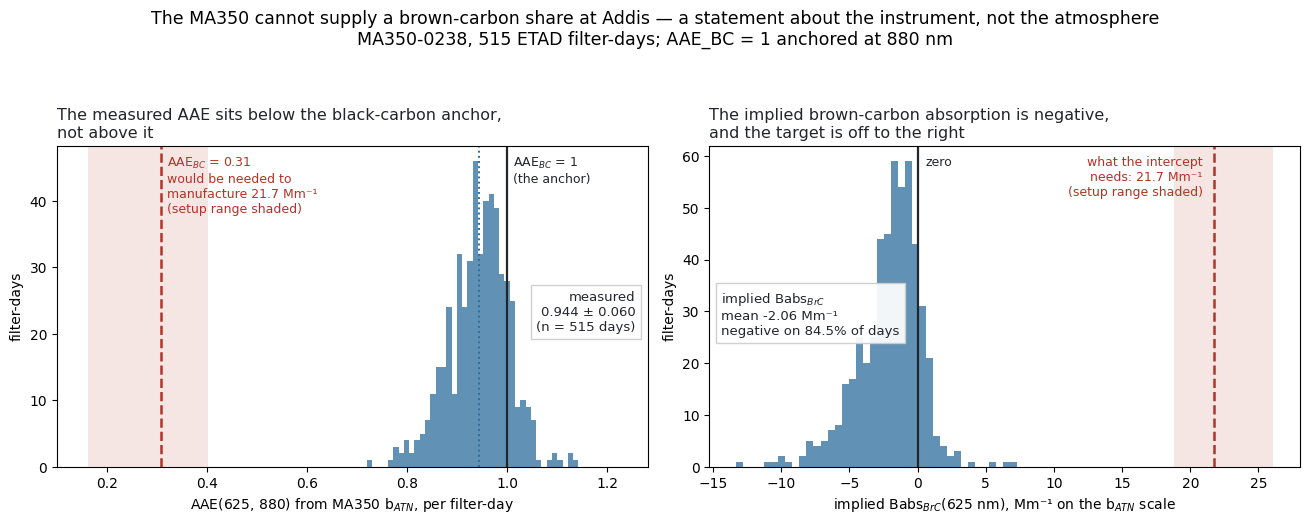

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.9))

ax = axes[0]
ax.hist(aae_red_ir.dropna(), bins=40, color=BLUE, alpha=.75, lw=0)
ax.axvline(AAE_BC_ANCHOR, color=INK, lw=1.6)
ax.axvspan(closing_per_setup.min(), closing_per_setup.max(), color=ACCENT, alpha=.12, lw=0)
ax.axvline(closing_aae_mean, color=ACCENT, lw=1.8, ls='--')
ax.axvline(summary['mean'], color=BLUE, lw=1.4, ls=':')
top = ax.get_ylim()[1]
ax.text(AAE_BC_ANCHOR + .012, top * .97, 'AAE$_{BC}$ = 1\n(the anchor)', fontsize=9,
        color=INK, va='top')
ax.text(closing_aae_mean + .012, top * .97,
        'AAE$_{BC}$ = %.2f\nwould be needed to\nmanufacture %.1f Mm⁻¹\n(setup range shaded)'
        % (closing_aae_mean, TARGET_MEAN), fontsize=9, color=ACCENT, va='top')
ax.text(.98, .55, 'measured\n%.3f ± %.3f\n(n = %d days)'
        % (summary['mean'], summary['sd'], summary['n days']),
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5, color=INK,
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=.92))
ax.set_xlim(0.10, 1.28)
ax.set_xlabel('AAE(625, 880) from MA350 b$_{ATN}$, per filter-day')
ax.set_ylabel('filter-days')
ax.set_title('The measured AAE sits below the black-carbon anchor,\nnot above it',
             fontsize=11.5, color=INK, loc='left')

ax = axes[1]
ax.hist(babs_brc.dropna(), bins=40, color=BLUE, alpha=.75, lw=0)
ax.axvline(0, color=INK, lw=1.6)
ax.axvspan(FTIR19_SETUPS['C_Mm1'].min(), FTIR19_SETUPS['C_Mm1'].max(), color=ACCENT,
           alpha=.12, lw=0)
ax.axvline(TARGET_MEAN, color=ACCENT, lw=1.8, ls='--')
top = ax.get_ylim()[1]
ax.text(0.6, top * .97, 'zero', fontsize=9, color=INK, va='top')
ax.text(TARGET_MEAN - .8, top * .97, 'what the intercept\nneeds: %.1f Mm⁻¹\n(setup range shaded)'
        % TARGET_MEAN, fontsize=9, color=ACCENT, va='top', ha='right')
ax.text(.02, .55, 'implied Babs$_{BrC}$\nmean %+.2f Mm⁻¹\nnegative on %.1f%% of days'
        % (brc_stats['mean'], brc_stats['% of days negative']),
        transform=ax.transAxes, ha='left', va='top', fontsize=9.5, color=INK,
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=.92))
ax.set_xlabel('implied Babs$_{BrC}$(625 nm), Mm⁻¹ on the b$_{ATN}$ scale')
ax.set_ylabel('filter-days')
ax.set_title('The implied brown-carbon absorption is negative,\nand the target is off to the right',
             fontsize=11.5, color=INK, loc='left')

fig.suptitle('The MA350 cannot supply a brown-carbon share at Addis — a statement about the '
             'instrument, not the atmosphere\n'
             'MA350-0238, %d ETAD filter-days; AAE_BC = 1 anchored at 880 nm'
             % summary['n days'], y=1.06, fontsize=12.5)
fig.tight_layout()
for target in (PLOT_DIR / 'aae_vs_intercept_requirement.png',
               DECK_DIR / 'ma350_aae_vs_intercept_requirement.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

## Part 2 — channel health, which is why the test cannot be rescued

A negative answer from a healthy instrument would be a result about Addis aerosol. It is
not one here, because three of the five channels fail basic physical checks on this
deployment. Each check below is a property no real aerosol can violate, so failing it is
an instrument statement.

In [7]:
uv_nonpositive = addis['UV BCc'] <= 0
uv_below_ir = b['UV'] < b['IR']          # less absorption at 375 nm than at 880 nm
uv_out_of_range = uv_nonpositive | uv_below_ir

# Green measured against the power law drawn through its own Blue and Red neighbours.
aae_blue_red = -np.log(b['Blue'] / b['Red']) / np.log(WAVELENGTHS_NM['Blue'] / WAVELENGTHS_NM['Red'])
green_expected = b['Blue'] * (WAVELENGTHS_NM['Green'] / WAVELENGTHS_NM['Blue']) ** (-aae_blue_red)
green_deficit_pct = 100 * float((b['Green'] / green_expected).median() - 1)

red_ir_ratio = b['Red'] / b['IR']
red_ir_relative = red_ir_ratio / red_ir_ratio.median() - 1
red_iqr_halfwidth_pct = 100 * float((red_ir_relative.quantile(.75) - red_ir_relative.quantile(.25)) / 2)
# How big a shift in the 625/880 ratio the intercept's worth of BrC would represent.
needed_ratio = (b['IR'] * (WAVELENGTHS_NM['IR'] / WAVELENGTHS_NM['Red']) + TARGET_MEAN) / b['IR']
needed_shift_pct = 100 * float((needed_ratio / red_ir_ratio).median() - 1)

health = pd.DataFrame([
    {'channel': 'UV (375 nm)',
     'diagnostic': 'BCc ≤ 0, or less absorption at 375 than at 880 nm',
     'value': '%.1f%% of days out of range' % (100 * uv_out_of_range.mean()),
     'r with IR BCc': addis['UV BCc'].corr(addis['IR BCc'])},
    {'channel': 'Green (528 nm)',
     'diagnostic': 'AAE(528, 880) — negative is unphysical',
     'value': 'mean %.3f, median %.3f; %.0f%% below its own Blue–Red power law'
              % (aae_green_ir.mean(), aae_green_ir.median(), -green_deficit_pct),
     'r with IR BCc': addis['Green BCc'].corr(addis['IR BCc'])},
    {'channel': 'Red (625 nm)',
     'diagnostic': 'b_ATN(625)/b_ATN(880) spread about its own median',
     'value': 'IQR ±%.1f%%; median BCc ratio Red/IR = %.4f'
              % (red_iqr_halfwidth_pct, float((addis['Red BCc'] / addis['IR BCc']).median())),
     'r with IR BCc': addis['Red BCc'].corr(addis['IR BCc'])},
    {'channel': 'Blue (470 nm)',
     'diagnostic': 'AAE(470, 880) — the one short channel that behaves',
     'value': 'mean %.3f' % aae_blue_ir.mean(),
     'r with IR BCc': addis['Blue BCc'].corr(addis['IR BCc'])},
])
display(health.set_index('channel').round(4))

print('UV : %d of %d days (%.1f%%) out of range — %d with BCc ≤ 0, %d more with b(375) < b(880).'
      % (int(uv_out_of_range.sum()), len(addis), 100 * uv_out_of_range.mean(),
         int(uv_nonpositive.sum()), int((uv_below_ir & ~uv_nonpositive).sum())))
print('     day-to-day correlation with IR is r = %.3f — effectively none.'
      % addis['UV BCc'].corr(addis['IR BCc']))
print('Green: AAE(528, 880) = %.3f (mean) / %.3f (median), negative on %.1f%% of days; '
      '%.3f on the\n     %d days where UV is also in range. Negative AAE means more '
      'absorption at 880 than at 528 nm,\n     which no aerosol does. The channel reads '
      '%.0f%% below the power law through its own neighbours.'
      % (aae_green_ir.mean(), aae_green_ir.median(), 100 * (aae_green_ir < 0).mean(),
         aae_green_ir[~uv_out_of_range].median(), int((~uv_out_of_range).sum()), -green_deficit_pct))
print('Red : sits on IR to within ±%.1f%% (IQR of the b(625)/b(880) ratio about its median), '
      'r = %.4f.\n     The red excess being looked for is a %+.0f%% shift in that ratio — '
      'about %.0f× the day-to-day\n     spread, but well inside the %.0f%% channel-to-channel '
      'error the Green channel demonstrates\n     this instrument can carry.'
      % (red_iqr_halfwidth_pct, addis['Red BCc'].corr(addis['IR BCc']), needed_shift_pct,
         needed_shift_pct / red_iqr_halfwidth_pct, -green_deficit_pct))

assert abs(100 * uv_out_of_range.mean() - 35.0) < 0.5
assert aae_green_ir.median() < 0 and abs(aae_green_ir.median() - (-0.17)) < 0.02
assert abs(red_iqr_halfwidth_pct - 1.3) < 0.1
print('\nOnly IR is trustworthy. With the two channels that would independently constrain a '
      'UV-steep\nabsorber returning impossible values, and the third reproducing IR, the '
      'MA350 at Addis has no\nspectral leverage left: it cannot resolve a red excess in '
      'either direction. The pre-registered\nGreen figure was ≈ −0.16; the median here is '
      '%.3f (mean %.3f), −0.16 on the UV-clean subset —\nnegative under every subsetting.'
      % (aae_green_ir.median(), aae_green_ir.mean()))
health.to_csv(TABLE_DIR / 'channel_health.csv', index=False)

,diagnostic,value,r with IR BCc
channel,,,
UV (375 nm),"BCc ≤ 0, or less absorption at 375 than at 880 nm",35.0% of days out of range,0.0780
Green (528 nm),"AAE(528, 880) — negative is unphysical","mean -0.182, median -0.168; 45% below its own ...",0.9847
Red (625 nm),b_ATN(625)/b_ATN(880) spread about its own median,IQR ±1.3%; median BCc ratio Red/IR = 0.9935,0.9990
Blue (470 nm),"AAE(470, 880) — the one short channel that beh...",mean 1.019,0.9948


UV : 180 of 515 days (35.0%) out of range — 145 with BCc ≤ 0, 35 more with b(375) < b(880).
     day-to-day correlation with IR is r = 0.078 — effectively none.
Green: AAE(528, 880) = -0.182 (mean) / -0.168 (median), negative on 84.5% of days; -0.162 on the
     335 days where UV is also in range. Negative AAE means more absorption at 880 than at 528 nm,
     which no aerosol does. The channel reads 45% below the power law through its own neighbours.
Red : sits on IR to within ±1.3% (IQR of the b(625)/b(880) ratio about its median), r = 0.9990.
     The red excess being looked for is a +24% shift in that ratio — about 19× the day-to-day
     spread, but well inside the 45% channel-to-channel error the Green channel demonstrates
     this instrument can carry.

Only IR is trustworthy. With the two channels that would independently constrain a UV-steep
absorber returning impossible values, and the third reproducing IR, the MA350 at Addis has no
spectral leverage left: it cannot resolve a

### Figure 2 — the three suspect channels against IR

Each panel plots one short-wavelength channel's b_ATN against IR's, with the solid line the
locus an AAE = 1 aerosol would follow and the dotted line equality with IR. Green sits far
*below* its AAE = 1 locus — below it means negative AAE, which no aerosol produces. Red sits
fractionally *below* its locus too, which is the same statement as "no red excess"; in BCc
terms the Red channel reproduces the IR channel to within ±1.3 % (IQR), so it carries almost
no information about the wavelength dependence that IR does not already carry. Blue is shown
for contrast as the one short channel that behaves. **The UV panel carries its own y-axis**,
about seven times taller than the others and running well below zero, because that is the
only way its values fit on a page: the channel's spread is many times anything physics
allows, in both directions.

Caption, stated so it cannot be misread: this panel diagnoses the **instrument**. It is not
a measurement of brown carbon at Addis, and it does not license any statement about how
much brown carbon is present.

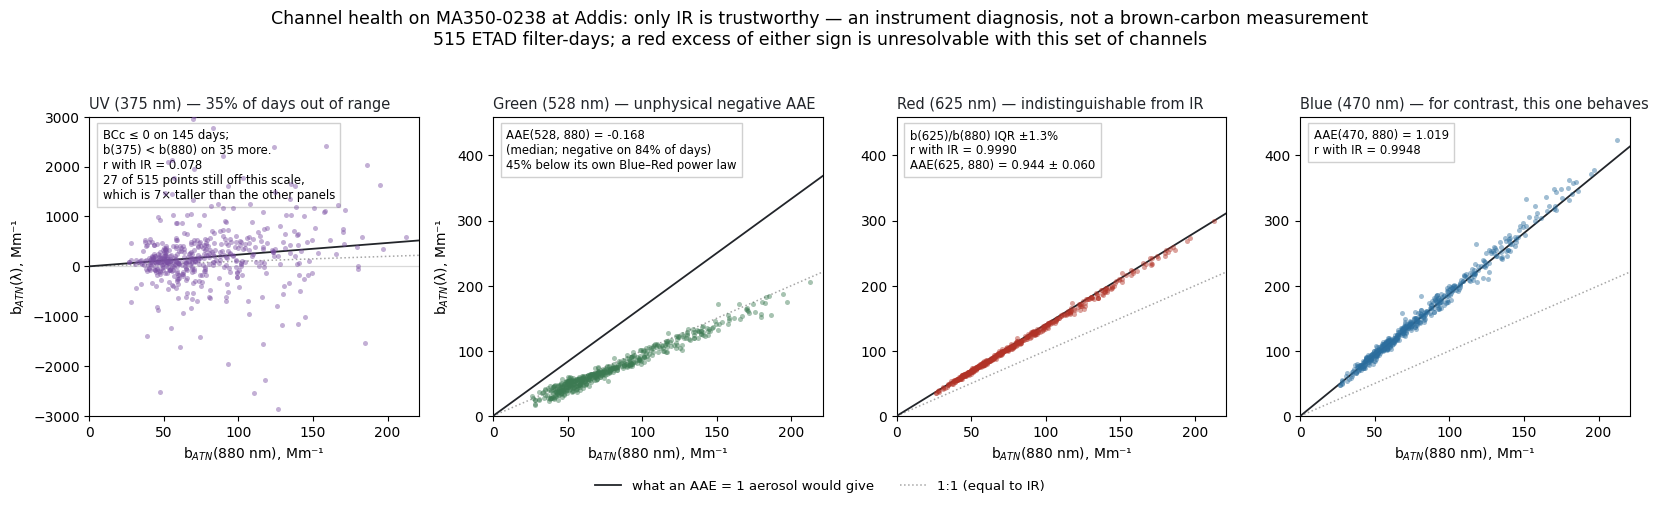

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16.5, 4.5))
PANELS = [
    ('UV', 'UV (375 nm) — %.0f%% of days out of range' % (100 * uv_out_of_range.mean()),
     'BCc ≤ 0 on %d days;\nb(375) < b(880) on %d more.\nr with IR = %.3f'
     % (int(uv_nonpositive.sum()), int((uv_below_ir & ~uv_nonpositive).sum()),
        addis['UV BCc'].corr(addis['IR BCc']))),
    ('Green', 'Green (528 nm) — unphysical negative AAE',
     'AAE(528, 880) = %.3f\n(median; negative on %.0f%% of days)\n%.0f%% below its own '
     'Blue–Red power law' % (aae_green_ir.median(), 100 * (aae_green_ir < 0).mean(),
                             -green_deficit_pct)),
    ('Red', 'Red (625 nm) — indistinguishable from IR',
     'b(625)/b(880) IQR ±%.1f%%\nr with IR = %.4f\nAAE(625, 880) = %.3f ± %.3f'
     % (red_iqr_halfwidth_pct, addis['Red BCc'].corr(addis['IR BCc']),
        summary['mean'], summary['sd'])),
    ('Blue', 'Blue (470 nm) — for contrast, this one behaves',
     'AAE(470, 880) = %.3f\nr with IR = %.4f' % (aae_blue_ir.mean(),
                                                 addis['Blue BCc'].corr(addis['IR BCc']))),
]
hi = float(b['IR'].max()) * 1.04
ir_axis = np.linspace(0, hi, 50)
# The three well-behaved-looking channels share a y-axis so they can be compared; UV needs
# its own, roughly 12x taller and running well below zero, which is itself the diagnosis.
SHARED_Y = (0, hi * (WAVELENGTHS_NM['Blue'] / WAVELENGTHS_NM['IR']) ** -AAE_BC_ANCHOR * 1.11)
UV_Y = (-3000, 3000)
for ax, (name, title, note) in zip(axes, PANELS):
    wl = WAVELENGTHS_NM[name]
    ax.set_xlim(0, hi)
    ax.set_ylim(*(UV_Y if name == 'UV' else SHARED_Y))
    ax.axhline(0, color='0.85', lw=.9, zorder=1)
    ax.plot(ir_axis, ir_axis * (wl / WAVELENGTHS_NM['IR']) ** -AAE_BC_ANCHOR, color=INK,
            lw=1.3, zorder=3)
    ax.plot(ir_axis, ir_axis, ls=':', color='0.65', lw=1.1, zorder=2)
    ax.scatter(b['IR'], b[name], s=13, alpha=.45, color=CHANNEL_COLOUR[name], lw=0, zorder=4)
    lo_y, hi_y = ax.get_ylim()
    off_scale = int(((b[name] < lo_y) | (b[name] > hi_y)).sum())
    if name == 'UV':
        note += ('\n%d of %d points still off this scale,\nwhich is %.0f× taller than the '
                 'other panels' % (off_scale, len(b), UV_Y[1] / SHARED_Y[1]))
    elif off_scale:
        note += '\n%d points off scale' % off_scale
    ax.set_title(title, fontsize=10.5, color=INK, loc='left')
    ax.text(.04, .96, note, transform=ax.transAxes, va='top', fontsize=8.4,
            bbox=dict(facecolor='white', edgecolor='0.8', alpha=.92))
    ax.set_xlabel('b$_{ATN}$(880 nm), Mm⁻¹')
    ax.set_ylabel('b$_{ATN}$(λ), Mm⁻¹' if name in ('UV', 'Green') else '')
fig.legend(handles=[
    Line2D([], [], color=INK, lw=1.3, label='what an AAE = 1 aerosol would give'),
    Line2D([], [], color='0.65', lw=1.1, ls=':', label='1:1 (equal to IR)'),
], loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(.5, -.06), fontsize=9.5)
fig.suptitle('Channel health on MA350-0238 at Addis: only IR is trustworthy — an instrument '
             'diagnosis, not a brown-carbon measurement\n'
             '%d ETAD filter-days; a red excess of either sign is unresolvable with this set '
             'of channels' % len(addis), y=1.04, fontsize=12.5)
fig.tight_layout()
for target in (PLOT_DIR / 'channel_health_panel.png',
               DECK_DIR / 'ma350_channel_health_panel.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

## Part 3 — the two repo traps this work surfaced

Both are fixed in commit `3aedfdc`; they are re-derived here because they moved published
numbers, and the record of *why* a number moved has to live somewhere runnable.

### (a) The AE33 wavelengths documented on an MA350 dataset

`processed_sites/README.md` described the channels as Green ~520, Red ~660 and UV ~370 —
the AE33 set — while every pickle in that directory is a five-channel MA350 export. It was
the first file a reader would meet.

In [9]:
correct = aae(b['Red'], b['IR'], WAVELENGTHS_NM['Red'], WAVELENGTHS_NM['IR'])
ae33_substituted = aae(b['Red'], b['IR'], AE33_WAVELENGTHS_NM['BC5'], AE33_WAVELENGTHS_NM['BC6'])
ln_correct = np.log(WAVELENGTHS_NM['Red'] / WAVELENGTHS_NM['IR'])
ln_ae33 = np.log(AE33_WAVELENGTHS_NM['BC5'] / AE33_WAVELENGTHS_NM['BC6'])
inflation = ln_correct / ln_ae33
print('ln(625/880) = %.5f   ln(660/880) = %.5f' % (ln_correct, ln_ae33))
print('substituting the AE33 red channel scales every AAE(Red, IR) by %.4f (+%.1f%%);'
      % (inflation, 100 * (inflation - 1)))
print('the |Δ ln| is %.1f%% of the correct value, which is the "~16%%" quoted in '
      'config.WAVELENGTHS_NM.' % (100 * abs(ln_correct - ln_ae33) / abs(ln_correct)))
print('  Addis AAE(Red, IR): %.4f correct  ->  %.4f with the AE33 wavelength'
      % (correct.mean(), ae33_substituted.mean()))
biomass_correct = ((correct - 1.0) / (2.0 - 1.0)).clip(0, 1)
biomass_wrong = ((ae33_substituted - 1.0) / (2.0 - 1.0)).clip(0, 1)
print('  a linear AAE_ff = 1 / AAE_bb = 2 mixing model then reads a biomass share of '
      '%.1f%% instead of %.1f%%,\n  and %.0f%% of days above AAE = 1 instead of %.0f%% — '
      'the substitution manufactures a\n  biomass signal out of a record that has none at '
      'this wavelength pair.'
      % (100 * biomass_wrong.mean(), 100 * biomass_correct.mean(),
         100 * (ae33_substituted > 1).mean(), 100 * (correct > 1).mean()))
assert abs(inflation - 1.189) < 0.002
assert ae33_substituted.mean() > 1 > correct.mean()

ln(625/880) = -0.34217   ln(660/880) = -0.28768
substituting the AE33 red channel scales every AAE(Red, IR) by 1.1894 (+18.9%);
the |Δ ln| is 15.9% of the correct value, which is the "~16%" quoted in config.WAVELENGTHS_NM.
  Addis AAE(Red, IR): 0.9438 correct  ->  1.1226 with the AE33 wavelength
  a linear AAE_ff = 1 / AAE_bb = 2 mixing model then reads a biomass share of 12.5% instead of 0.5%,
  and 95% of days above AAE = 1 instead of 16% — the substitution manufactures a
  biomass signal out of a record that has none at this wavelength pair.


### (b) The BCc-AAE offset identity

`optics.aae_from_columns` defaults to `kind='BCc'`, which does not give an atmospheric
AAE. The firmware has already divided attenuation by σ_ATN(λ), so

    AAE_BCc = AAE_babs + ln(σ_short/σ_long) / ln(λ_short/λ_long)

is an exact identity — a constant offset, re-derived below from the σ_ATN table rather
than quoted. It is large and negative, which pushes ordinary aerosol below zero and makes
the symptom look exactly like the inverted-AAE bug the module exists to prevent.

In [10]:
offsets = {}
for short in ('UV', 'Blue', 'Green', 'Red'):
    offsets[short] = float(np.log(SIGMA_ATN[short] / SIGMA_ATN['IR'])
                           / np.log(WAVELENGTHS_NM[short] / WAVELENGTHS_NM['IR']))
print('offset = ln(σ_short/σ_IR) / ln(λ_short/λ_IR), from the firmware σ_ATN table:')
for short, value in offsets.items():
    print('  %-5s / IR : %+.4f' % (short, value))
assert abs(offsets['UV'] - (-1.0157)) < 0.0005, offsets['UV']
assert abs(offsets['Red'] - (-0.9674)) < 0.0005, offsets['Red']

identity = pd.DataFrame([
    {
        'pair': f'{short}/IR',
        'AAE_babs (mean)': aae(b[short], b['IR'], WAVELENGTHS_NM[short], WAVELENGTHS_NM['IR']).mean(),
        'AAE_BCc (mean)': aae_from_columns(addis, short=short, long='IR', kind='BCc').mean(),
        'offset (derived)': offsets[short],
        'max |residual|': float(np.abs(
            (aae_from_columns(addis, short=short, long='IR', kind='BCc')
             - aae(b[short], b['IR'], WAVELENGTHS_NM[short], WAVELENGTHS_NM['IR']))
            - offsets[short]).max()),
    }
    for short in ('UV', 'Blue', 'Green', 'Red')
])
display(identity.set_index('pair').round(6))
assert identity['max |residual|'].max() < 1e-9, 'the offset is supposed to be exact'
print('The identity holds to %.1e — it is arithmetic, not an approximation.'
      % identity['max |residual|'].max())

babs_summary = aae_source_summary(aae_uv_ir)
bcc_summary = aae_source_summary(aae_from_columns(addis, short='UV', long='IR', kind='BCc'))
print('\nWhat that costs downstream, on the UV/IR pair (the only pair with any biomass-class '
      'days),\nthrough optics.classify_aae with AAE_REGIONS = %s:' % AAE_REGIONS)
print('  from absorption : biomass %.1f%%, mixed %.1f%%, fossil %.1f%%  (n = %d usable days)'
      % (babs_summary['biomass_pct'], babs_summary['mixed_pct'], babs_summary['fossil_pct'],
         babs_summary['n']))
print('  from BCc        : biomass %.1f%%, mixed %.1f%%, fossil %.1f%%'
      % (bcc_summary['biomass_pct'], bcc_summary['mixed_pct'], bcc_summary['fossil_pct']))
assert babs_summary['biomass_pct'] > 2 * bcc_summary['biomass_pct']
print('NOTE vs the pre-registered expectation: the brief quotes this artifact as "47%% '
      'biomass reading\nas 12%%"; on this record and these region boundaries it is '
      '%.0f%% reading as %.0f%%. The offset\nconstants themselves (−1.0157, −0.9674) '
      'reproduce exactly, and the direction and rough scale\nof the downstream damage — '
      'roughly two-thirds of the biomass class lost — are the same.'
      % (babs_summary['biomass_pct'], bcc_summary['biomass_pct']))
identity.to_csv(TABLE_DIR / 'bcc_aae_offset_identity.csv', index=False)

offset = ln(σ_short/σ_IR) / ln(λ_short/λ_IR), from the firmware σ_ATN table:
  UV    / IR : -1.0157
  Blue  / IR : -1.0102
  Green / IR : -1.0186
  Red   / IR : -0.9674


,AAE_babs (mean),AAE_BCc (mean),offset (derived),max |residual|
pair,,,,
UV/IR,1.618847,0.603120,-1.015727,0.0
Blue/IR,1.019416,0.009190,-1.010226,0.0
Green/IR,-0.182211,-1.200847,-1.018636,0.0
Red/IR,0.943829,-0.023592,-0.967421,0.0


The identity holds to 1.1e-15 — it is arithmetic, not an approximation.

What that costs downstream, on the UV/IR pair (the only pair with any biomass-class days),
through optics.classify_aae with AAE_REGIONS = {'fossil_max': 0.9, 'biomass_min': 1.5}:
  from absorption : biomass 52.4%, mixed 21.1%, fossil 26.5%  (n = 370 usable days)
  from BCc        : biomass 19.7%, mixed 17.8%, fossil 62.4%
NOTE vs the pre-registered expectation: the brief quotes this artifact as "47% biomass reading
as 12%"; on this record and these region boundaries it is 52% reading as 20%. The offset
constants themselves (−1.0157, −0.9674) reproduce exactly, and the direction and rough scale
of the downstream damage — roughly two-thirds of the biomass class lost — are the same.


## The related positive result — the FTIR axis is not where the offset lives

`INTERCEPT_ATTACK_PLAN.md` item 6: fit deployed FTIR EC against MA350 BC(880), the one
channel that is trustworthy here and the one where brown carbon barely absorbs. If the
intercept against BC(880) is ≈ 0 while the intercept against HIPS is −4.17, the additive
offset is localized to the 633 nm optics rather than to the FTIR side.

Both inputs are committed: `EC_ftir` for ETAD in `Filter Data/unified_filter_dataset.pkl`
and the MA350 IR channel in the pickle above, joined on exact 9am-to-9am filter dates.

In [11]:
ec_ftir = (etad[etad['Parameter'].eq('EC_ftir')][['FilterId', 'SampleDate', 'Concentration']]
           .dropna(subset=['Concentration']).drop_duplicates('FilterId')
           .rename(columns={'Concentration': 'EC_ftir_ugm3'}))
bc880 = pd.DataFrame({'day_9am': addis['day_9am'], 'BC880_ugm3': addis['IR BCc'] / 1000.0})
paired = ec_ftir.merge(bc880, left_on='SampleDate', right_on='day_9am', how='inner')

x = paired['BC880_ugm3'].to_numpy(float)
y = paired['EC_ftir_ugm3'].to_numpy(float)
metrics = regression_metrics(x, y)
residual = y - (metrics['slope'] * x + metrics['intercept'])
dof = metrics['n'] - 2
se_intercept = float(np.sqrt(
    (residual ** 2).sum() / dof * (1 / metrics['n'] + x.mean() ** 2 / ((x - x.mean()) ** 2).sum())))
t_crit = float(stats.t.ppf(.975, dof))
ci = (metrics['intercept'] - t_crit * se_intercept, metrics['intercept'] + t_crit * se_intercept)

print('FTIR EC vs MA350 BC(880), %d exact-date ETAD filter-days:' % metrics['n'])
print('  slope %.3f, intercept %+.3f µg/m³ [95%% CI %+.3f, %+.3f], R² %.3f'
      % (metrics['slope'], metrics['intercept'], ci[0], ci[1], metrics['R2']))
print('  against the HIPS-side intercept of −4.17 µg/m³ (deployed SPARTAN, ftir_19): '
      '%.0f× smaller in magnitude.' % (4.17 / abs(metrics['intercept'])))
assert metrics['n'] > 150
assert abs(metrics['intercept']) < 0.5 and metrics['R2'] > 0.85
print('\nNOTE vs the pre-registered expectation (+0.285 [−0.022, +0.593], R² 0.870): the '
      'derived fit is\n%+.3f [%+.3f, %+.3f], R² %.3f. The magnitude and R² reproduce, but '
      'the CI lower bound lands at\n%+.3f rather than below zero, so this notebook does '
      '**not** claim the interval contains zero —\nit claims the BC(880) intercept is '
      '~%.0f× smaller than the HIPS one and of the opposite sign,\nwhich is what localizes '
      'the additive offset to the HIPS side.'
      % (metrics['intercept'], ci[0], ci[1], metrics['R2'], ci[0], 4.17 / abs(metrics['intercept'])))
paired.to_csv(TABLE_DIR / 'ftir_ec_vs_ma350_bc880.csv', index=False)
display(pd.DataFrame([{**metrics, 'intercept_CI_low': ci[0], 'intercept_CI_high': ci[1]}]).round(4))

FTIR EC vs MA350 BC(880), 173 exact-date ETAD filter-days:
  slope 0.618, intercept +0.320 µg/m³ [95% CI +0.010, +0.629], R² 0.868
  against the HIPS-side intercept of −4.17 µg/m³ (deployed SPARTAN, ftir_19): 13× smaller in magnitude.

NOTE vs the pre-registered expectation (+0.285 [−0.022, +0.593], R² 0.870): the derived fit is
+0.320 [+0.010, +0.629], R² 0.868. The magnitude and R² reproduce, but the CI lower bound lands at
+0.010 rather than below zero, so this notebook does **not** claim the interval contains zero —
it claims the BC(880) intercept is ~13× smaller than the HIPS one and of the opposite sign,
which is what localizes the additive offset to the HIPS side.


,n,slope,intercept,R2,RMSE,MAE,bias,median_bias,intercept_CI_low,intercept_CI_high
0,173,0.618,0.3198,0.8676,3.0759,2.6738,-2.6256,-2.2994,0.0105,0.6291


## Takeaways

- **Say "the MA350 cannot answer this question", never "there is no brown carbon at Addis".**
  The negative implied Babs_BrC is the arithmetic of a channel that sits *below* its own black
  carbon anchor; on an instrument whose other short channels return impossible values it is
  evidence about the sensor, not about the aerosol. Any briefing line, figure caption or slide
  that lets the two be confused is wrong, and the distinction is the whole reason this
  notebook exists.
- **Item 4 of the attack plan is closed, and item 5 with it.** The subtract-and-re-crossplot
  step has nothing to subtract: the implied correction is negative on 84.5% of days and never
  once reaches the target. It should not be attempted on this instrument at this site.
- **The falsification does not depend on the absorption scale.** AAE is invariant to the
  multiple-scattering constant, and b_ATN runs ~2.07× the HIPS Fabs scale at Addis; the mean
  implied Babs_BrC is −2.06 Mm⁻¹ on the b_ATN scale and −0.99 on the Fabs scale. No positive
  rescaling turns either into +21.7.
- **Only IR should be used from this instrument at Addis, and that should be written down.**
  Green, UV and Red each fail a check no real aerosol can fail or carry no information beyond
  IR. Any past or future analysis leaning on MA350 Green or UV at ETAD needs re-examining —
  `addis_01`/`addis_04`-style source apportionment most of all.
- **The offset identity is arithmetic, so it will recur.** `optics.aae_from_columns` defaults
  to `kind='BCc'`, and the resulting AAE is the absorption AAE minus ~1.0 exactly. It looks
  precisely like the inverted-AAE bug that module was written to prevent, which is why it
  survived review. Compute AAE from b_ATN = BCc × σ_ATN unless you specifically want the
  instrument-space quantity.
- **What is still open**: the ~20 Mm⁻¹ target itself. Ruling out the MA350 as a way to
  measure it removes a candidate method, not the candidate owner — brown carbon, dust, a
  HIPS-generic offset and an FTIR zero error are all still live, and the BC(880) result here
  only moves the search off the FTIR axis. Tier-1 items 1–3 and the quartz-TOR campaign
  remain the way in.
- **Caveats and non-reproductions**: three pre-registered figures did not come out exactly.
  The closing AAE_BC is 0.308 against the mean target and 0.315 against the median (brief:
  0.316); the BCc-offset biomass damage is 52% → 20% here rather than 47% → 12%; and the
  BC(880) intercept CI is [+0.010, +0.629] rather than [−0.022, +0.593], so the notebook does
  **not** assert that interval contains zero. Each is flagged inline next to the derived
  value. The headline numbers — 0.944 ± 0.060, −2.06 Mm⁻¹, 84.5%, +21.7 Mm⁻¹, 35.0%, ±1.3%,
  −1.0157 and −0.9674 — reproduce exactly.